In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Data Preprocessing
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
del df['Cabin']

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [8]:
df.dropna(axis = 0, inplace=True)
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [9]:
df.shape

(712, 11)

In [10]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df.shape

(712, 8)

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [13]:
x = df.iloc[:, 1:]
y = df['Survived']

In [14]:
y.value_counts()

Survived
0    424
1    288
Name: count, dtype: int64

In [15]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy = 'minority')
x, y = sm.fit_resample(x, y)

In [16]:
y.value_counts()

Survived
0    424
1    424
Name: count, dtype: int64

In [17]:
len(x)

848

In [18]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
comp = pca.fit_transform(x)

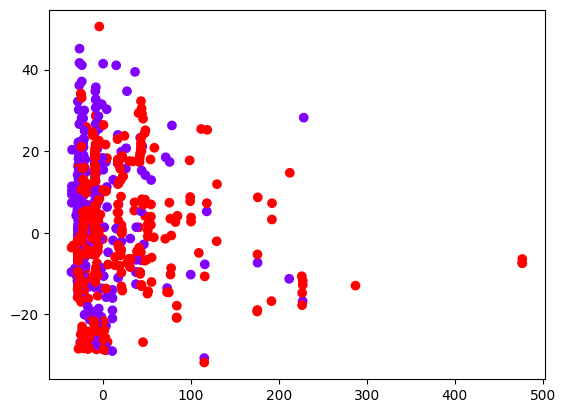

In [19]:
import matplotlib.pyplot as plt
plt.scatter(comp[:, 0], comp[:, 1], cmap = 'rainbow', c = y)
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1, shuffle=True)

Model Building

In [24]:
from sklearn.svm import LinearSVC, SVC
svc = LinearSVC()
svc.fit(x_train, y_train)

LinearSVC()

In [25]:
print(svc.score(x_train, y_train))
print(svc.score(x_test, y_test))

0.8112094395280236
0.8411764705882353


Linear

In [27]:
svc1 = SVC(kernel='linear')
svc1.fit(x_train, y_train)

SVC(kernel='linear')

In [31]:
print(svc1.score(x_train, y_train))
print(svc1.score(x_test, y_test))

0.7905604719764012
0.8352941176470589


In [29]:
svm2 = SVC(kernel = 'linear')
svm2.fit(x_train, y_train)

SVC(kernel='linear')

In [30]:
print(svm2.score(x_train, y_train))
print(svm2.score(x_test, y_test))

0.7905604719764012
0.8352941176470589


Non Linear SVM

In [34]:
from sklearn.svm import SVC
svm3 = SVC(kernel='rbf')
svm3.fit(x_train, y_train)

SVC()

In [35]:
svm4 = SVC(kernel = 'poly', degree = 3)
svm4.fit(x_train, y_train)

SVC(kernel='poly')

In [36]:
print(svm4.score(x_train, y_train))
print(svm4.score(x_test, y_test))

0.5693215339233039
0.5882352941176471
